# Testing if the integrator works

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from simulation import Simulation
from wisdom_holman import WisdomHolman
from particles import Particles
from particle import Particle
from data_io import DataIO
import constants
from physics import Physics

In [3]:
import h5py

In [4]:
print(Simulation)

<class 'simulation.Simulation'>


In [10]:
particles = Particles(constants.G)


particles.add_particle(Particle(0, [0,0,0], [0,0,0], 1.0, 0.01, 5700, None, "Sun"))
particles.add_particle(Particle(1, [1,0,0], [0,1,0], 3e-6, 0.001, 0, 0.3, "Earth"))
particles.add_particle(Particle(1, [3, 0, 0], [0.0, 0.5, 0], 3e-6, 0.001, 0, 0.2, 'Mars'))



print(particles._particles)

[Particle(name='Sun', ptype=0, m=1.0, r=0.01, pos=[0.0, 0.0, 0.0], vel=[0.0, 0.0, 0.0], hash=971582858), Particle(name='Earth', ptype=1, m=3e-06, r=0.001, pos=[1.0, 0.0, 0.0], vel=[0.0, 1.0, 0.0], hash=352818251), Particle(name='Mars', ptype=1, m=3e-06, r=0.001, pos=[3.0, 0.0, 0.0], vel=[0.0, 0.5, 0.0], hash=808579456)]


In [11]:
run = Simulation(particles=particles, integrator=WisdomHolman(), dataio=DataIO(const_g=constants.G), physics=Physics())

In [12]:
run.run(t0=0.0, tf=100.0, dt=0.01, output_every_n=1, handle_collisions=False)

In [13]:
import matplotlib.pyplot as plt

keys: ['Step_0', 'Step_1', 'Step_2'] ... Step_9
t[0], t[-1], len: 0.0 100.00000000001425 10001
pos shape: (10001, 3, 3)


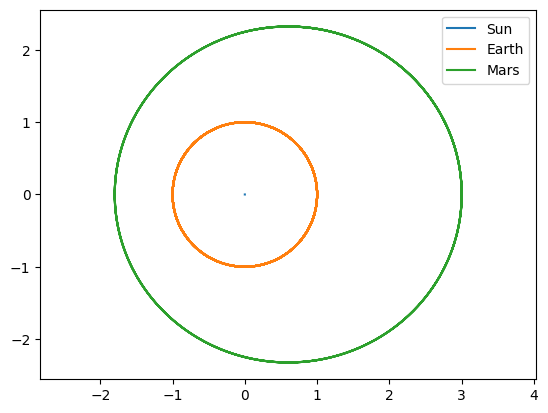

In [14]:
H5_PATH = "data.hdf5"

with h5py.File(H5_PATH, "r") as f:
    keys = sorted(
        [k for k in f.keys() if k.startswith("Step_")],
        key=lambda s: int(s.split("_")[1])
    )

    t_list, pos_list, vel_list = [], [], []
    for k in keys:
        g = f[k]
        t_list.append(g["time"][:])
        pos_list.append(g["pos"][:])
        vel_list.append(g["vel"][:])

t = np.concatenate(t_list)
pos = np.concatenate(pos_list)
vel = np.concatenate(vel_list)

# reshape if flattened (n_steps, 3N) -> (n_steps, N, 3)
if pos.ndim == 2:
    N = pos.shape[1] // 3
    pos = pos.reshape(pos.shape[0], N, 3)
if vel.ndim == 2:
    N2 = vel.shape[1] // 3
    vel = vel.reshape(vel.shape[0], N2, 3)

print("keys:", keys[:3], "...", keys[-1])
print("t[0], t[-1], len:", t[0], t[-1], len(t))
print("pos shape:", pos.shape)

# ---- pick indices: 0=Sun, 1=Earth ----
sun_i = 0
earth_i = 1
mars_i = 2

# Optional: mask out any rows where Earth got removed and became NaN
mask_e = np.isfinite(pos[:, earth_i, 0]) & np.isfinite(pos[:, earth_i, 1])
mask_m = np.isfinite(pos[:, mars_i, 0]) & np.isfinite(pos[:, mars_i, 1])

plt.figure()
plt.plot(pos[:, sun_i, 0], pos[:, sun_i, 1], label="Sun")
plt.plot(pos[mask_e, earth_i, 0], pos[mask_e, earth_i, 1], label="Earth")
plt.plot(pos[mask_m, mars_i, 0], pos[mask_m, mars_i, 1], label="Mars")
plt.axis("equal")
plt.legend()
plt.show()

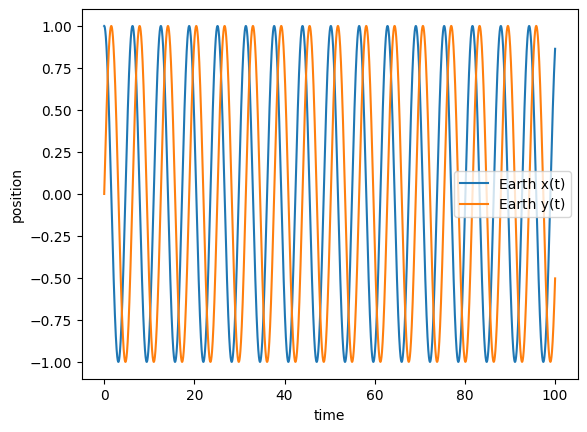

In [15]:
plt.figure()
plt.plot(t, pos[:, earth_i, 0], label="Earth x(t)")
plt.plot(t, pos[:, earth_i, 1], label="Earth y(t)")
plt.xlabel("time")
plt.ylabel("position")
plt.legend()
plt.show()

In [11]:
print("first 5 times:", t[:5])
print("first pos row:", pos[0])
print("first vel row:", vel[0])

first 5 times: [0.   0.01 0.02 0.03 0.04]
first pos row: [[0. 0. 0.]
 [1. 0. 0.]
 [3. 0. 0.]]
first vel row: [[0.  0.  0. ]
 [0.  1.  0. ]
 [0.  0.5 0. ]]
